In [ ]:
# Instala todas las bibliotecas de Python necesarias para el proyecto.
!pip install --quiet roboflow ultralytics imagehash opencv-python-headless tqdm pandas matplotlib pyyaml

# Importación de los módulos.
import os, glob, shutil, hashlib, random
from pathlib import Path
from PIL import Image
import imagehash
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml

# Parámetros del proyecto
ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "").strip()
if not ROBOFLOW_API_KEY:
    raise RuntimeError("Define la variable ROBOFLOW_API_KEY en tu entorno antes de descargar el dataset")
WORKSPACE = "david-7s579"
PROJECT_ID = "final_ds-qf0jg"
VERSION = 1

# Configuración de Directorios
ORIG_DIR = "dataset_original"
FINAL_DIR = "Dataset_Final"
random.seed(42)


# Función para estadistica

def get_dataset_stats(base_dir):
    try:
        with open(os.path.join(base_dir, "data.yaml")) as f:
            ycfg = yaml.safe_load(f)
        num_classes = ycfg['nc']
    except Exception:
        num_classes = 0

    num_images = len(glob.glob(f"{base_dir}/*/images/*"))
    num_annotations = 0
    for lbl_file in glob.glob(f"{base_dir}/*/labels/*.txt"):
        with open(lbl_file) as f:
            num_annotations += len([ln for ln in f if ln.strip()])

    return {"classes": num_classes, "images": num_images, "annotations": num_annotations}


In [ ]:
# Descarga desde Roboflow (formato YOLOv8)

# Importa la clase principal de Roboflow.
from roboflow import Roboflow

!rm -rf {ORIG_DIR} {FINAL_DIR}
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_ID)
dataset = project.version(VERSION).download("yolov8", location=ORIG_DIR)

# Capturar las estadísticas iniciales del dataset recién descargado.
stats_antes = get_dataset_stats(ORIG_DIR)
print(f"-> Clases iniciales: {stats_antes['classes']}")
print(f"-> Imágenes iniciales: {stats_antes['images']}")
print(f"-> Anotaciones iniciales: {stats_antes['annotations']}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to dataset_original in yolov8:: 100%|██████████| 128454/128454 [00:29<00:00, 4365.98it/s]


-> Clases iniciales: 32
-> Imágenes iniciales: 64221
-> Anotaciones iniciales: 71794


In [ ]:
# Normalización robusta de clases ['gun', 'knife']

# Construye la ruta al archivo de configuración 'data.yaml' del dataset original.
yaml_path = os.path.join(ORIG_DIR, "data.yaml")
with open(yaml_path) as f:
    ycfg = yaml.safe_load(f)

if isinstance(ycfg.get("names"), dict):
    id2name = {int(k): v for k, v in ycfg["names"].items()}
else:
    id2name = {i: v for i, v in enumerate(ycfg["names"])}

# Define la lista final de clases objetivo ('gun' clase 0, 'knife' clase 1).
TARGET = ["gun", "knife"]

def normalize_name(raw: str) -> str|None:
    s = raw.lower().strip().replace("-", "_")
    if ("knife" in s) or ("blade" in s) or ("cuchill" in s) or ("navaj" in s) or ("machete" in s):
        return "knife"
    if ("gun" in s) or ("handgun" in s) or ("pistol" in s) or ("revolver" in s) \
       or ("firearm" in s) or ("arma_de_fuego" in s) or (s == "arma") or ("hand_gun" in s):
        return "gun"
    return None

def normalize_split(split):
    lbl_dir = os.path.join(ORIG_DIR, split, "labels")
    img_dir = os.path.join(ORIG_DIR, split, "images")
    kept, removed = 0, 0
    if not os.path.isdir(lbl_dir):
        return kept, removed

    for fn in tqdm(os.listdir(lbl_dir), desc=f"Normalizando {split}"):
        if not fn.endswith(".txt"): continue
        p = os.path.join(lbl_dir, fn)
        with open(p) as f:
            lines = [ln.strip() for ln in f if ln.strip()]
        new_lines = []
        for ln in lines:
            parts = ln.split()
            if not parts: continue
            cid = int(parts[0])
            raw_name = id2name.get(cid, str(cid))
            uni = normalize_name(raw_name)

            if uni in TARGET:
                parts[0] = str(TARGET.index(uni))
                new_lines.append(" ".join(parts))

        if new_lines:
            with open(p, "w") as f:
                f.write("\n".join(new_lines))
            kept += 1
        else:
            os.remove(p); removed += 1
            stem = Path(fn).stem
            for ext in [".jpg",".jpeg",".png",".JPG",".JPEG",".PNG",".bmp"]:
                imgp = os.path.join(img_dir, stem+ext)
                if os.path.exists(imgp):
                    os.remove(imgp); break
    return kept, removed

# Ejecución de la Normalización
tot_k = tot_r = 0
for sp in ["train","val","test"]:
    k,r = normalize_split(sp)
    tot_k += k; tot_r += r
print(f"Etiquetas válidas: {tot_k} | pares imagen/label eliminados: {tot_r}")

# Actualiza el archivo 'data.yaml' para que refleje la nueva estructura de clases.
ycfg["names"] = ["gun", "knife"]
ycfg["nc"] = 2
with open(yaml_path, "w") as f:
    yaml.safe_dump(ycfg, f)
print("data.yaml actualizado con ['gun', 'knife']")

Normalizando test: 100%|██████████| 3692/3692 [00:00<00:00, 8584.29it/s]

Etiquetas válidas: 47072 | pares imagen/label eliminados: 13077
data.yaml actualizado con ['gun', 'knife']


In [ ]:
# Eliminación de duplicados (exactos + perceptuales)

def md5sum(path):
    h = hashlib.md5()
    with open(path,'rb') as f: h.update(f.read())
    return h.hexdigest()

def remove_exact_dupes(img_dir):
    seen, removed = {}, 0
    for img in tqdm(os.listdir(img_dir), desc="Duplicados exactos"):
        p = os.path.join(img_dir, img)
        if not os.path.isfile(p): continue
        h = md5sum(p)
        if h in seen:
            os.remove(p); removed += 1
            lbl = p.replace("images","labels")
            for ext in [".txt"]:
                cand = Path(lbl).with_suffix(ext)
                if cand.exists(): cand.unlink()
        else:
            seen[h] = p
    return removed

def remove_perceptual_dupes(img_dir, threshold=5):
    phashes, removed = {}, 0
    for img in tqdm(os.listdir(img_dir), desc="Duplicados perceptuales"):
        p = os.path.join(img_dir, img)
        if not os.path.isfile(p): continue
        try:
            h = imagehash.phash(Image.open(p))
        except:
            continue
        is_dup = any(abs(h - hh) <= threshold for hh in phashes.keys())
        if is_dup:
            os.remove(p); removed += 1
            lbl = p.replace("images","labels")
            cand = Path(lbl).with_suffix(".txt")
            if cand.exists(): cand.unlink()
        else:
            phashes[h] = p
    return removed

for sp in ["train","val","test"]:
    img_dir = os.path.join(ORIG_DIR, sp, "images")
    if os.path.isdir(img_dir):
        r1 = remove_exact_dupes(img_dir)
        r2 = remove_perceptual_dupes(img_dir, threshold=5)
        print(f"{sp.upper()}: exactos={r1}, perceptuales={r2}")

Duplicados perceptuales: 100%|██████████| 43857/43857 [46:52<00:00, 15.60it/s]


TRAIN: exactos=407, perceptuales=5509


Duplicados perceptuales: 100%|██████████| 2758/2758 [00:21<00:00, 128.96it/s]

TEST: exactos=50, perceptuales=630


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



 Anotaciones por clase (train+val+test):
 gun      25675
knife    18922
dtype: int64


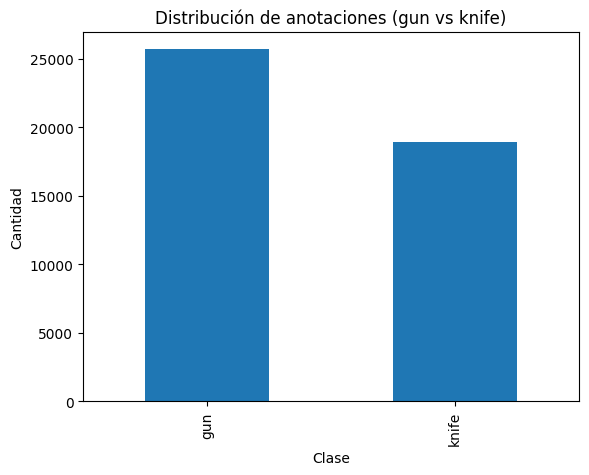

TRAIN → imágenes: 38348 | labels: 38349
  VAL → imágenes:     0 | labels:     0
 TEST → imágenes:  2128 | labels:  2128


In [ ]:
# EDA y verificación del estado del dataset después de la limpieza inicial.

def eda(base=ORIG_DIR):
    counts = {0:0, 1:0}

    for sp in ["train","val","test"]:
        for p in glob.glob(f"{base}/{sp}/labels/*.txt"):
            for ln in open(p):
                ln = ln.strip()
                if ln:
                    cid = int(ln.split()[0])
                    if cid in counts:
                        counts[cid] += 1

    s = pd.Series(counts); s.index = ["gun", "knife"]
    print("\n Anotaciones por clase (train+val+test):\n", s)

    if s.sum() > 0:
        s.plot(kind="bar"); plt.title("Distribución de anotaciones (gun vs knife)")
        plt.xlabel("Clase"); plt.ylabel("Cantidad"); plt.show()

    for sp in ["train","val","test"]:
        ni = len(glob.glob(f"{base}/{sp}/images/*"))
        nl = len(glob.glob(f"{base}/{sp}/labels/*.txt"))
        print(f"{sp.upper():>5} → imágenes: {ni:5d} | labels: {nl:5d}")

eda(ORIG_DIR)

In [ ]:
# Re-split a 80/10/10

# Crea el directorio principal para el dataset final.
os.makedirs(FINAL_DIR, exist_ok=True)
for d in [f"{FINAL_DIR}/{s}/images" for s in ["train","val","test"]] + \
         [f"{FINAL_DIR}/{s}/labels" for s in ["train","val","test"]]:
    os.makedirs(d, exist_ok=True)

# Recolección de todos los datos limpios.
pairs = []
for sp in ["train","val","test"]:
    for lbl in glob.glob(f"{ORIG_DIR}/{sp}/labels/*.txt"):
        stem = Path(lbl).stem
        img = None
        for ext in [".jpg",".jpeg",".png",".JPG",".JPEG",".PNG",".bmp"]:
            cand = f"{ORIG_DIR}/{sp}/images/{stem}{ext}"
            if os.path.exists(cand):
                img=cand; break
        if img: pairs.append((img, lbl))

print("Pares válidos totales (después de limpieza):", len(pairs))

# Nueva partición
random.shuffle(pairs)

# Calcula los puntos de corte (índices) para la división 80/10/10.
n = len(pairs)
split_train = int(0.80 * n)
split_val = int(0.90 * n)


train_pairs = pairs[:split_train]
val_pairs = pairs[split_train:split_val]
test_pairs = pairs[split_val:]

splits = {"train": train_pairs, "val": val_pairs, "test": test_pairs}

def cp(src, dst_dir):
    shutil.copy(src, os.path.join(dst_dir, os.path.basename(src)))

# Copia los archivos a las carpetas limpias
for sp, items in splits.items():
    for img, lbl in items:
        cp(img, f"{FINAL_DIR}/{sp}/images")
        cp(lbl, f"{FINAL_DIR}/{sp}/labels")

base_path = f"/content/{FINAL_DIR}"

with open(f"{FINAL_DIR}/data.yaml","w") as f:
    f.write(f"""
train: {base_path}/train/images
val: {base_path}/val/images
test: {base_path}/test/images

nc: 2
names: ['gun', 'knife']
""")

print(f"Split 80/10/10 creado en {FINAL_DIR} con rutas absolutas.")

Pares válidos totales (después de limpieza): 40476
Split 80/10/10 creado en Dataset_Final con rutas absolutas.



 Anotaciones por clase (train+val+test):
 gun      25674
knife    18922
dtype: int64


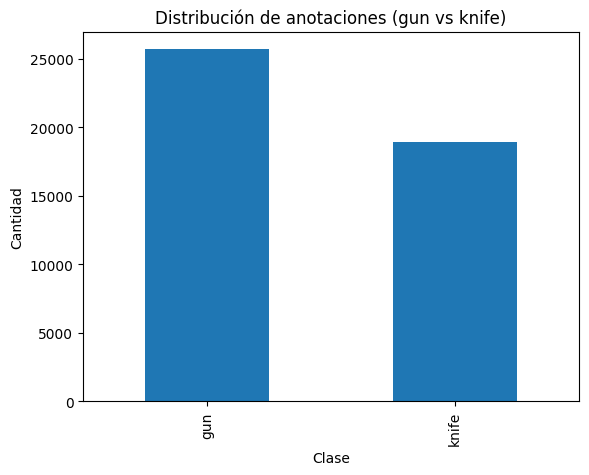

TRAIN → imágenes: 32380 | labels: 32380
  VAL → imágenes:  4048 | labels:  4048
 TEST → imágenes:  4048 | labels:  4048
Dataset limpio y dividido. Usa este YAML para entrenar:
Dataset_Final/data.yaml


In [ ]:
# EDA final sobre Dataset_Final (confirmación)

eda(FINAL_DIR)
print("Dataset limpio y dividido. Usa este YAML para entrenar:")
print(f"{FINAL_DIR}/data.yaml")

In [ ]:
# Resumen Final Comparativo

print("\n" + "="*50)
print("RESUMEN FINAL DEL PROCESO DE LIMPIEZA")
print("="*50)

# Calcula las estadísticas del dataset final y limpio.
stats_despues = get_dataset_stats(FINAL_DIR)

# Tabla comparativa.
print(f"{'Métrica':<20} | {'Antes':>10} | {'Después':>10} | {'Cambio (%)':>12}")
print("-"*60)

# Comparación de Clases
clases_antes = stats_antes['classes']
clases_despues = stats_despues['classes']
print(f"{'Nº de Clases':<20} | {clases_antes:>10} | {clases_despues:>10} | {'-':>12}")

# Comparación de Imágenes
img_antes = stats_antes['images']
img_despues = stats_despues['images']
cambio_img = ((img_despues - img_antes) / img_antes * 100) if img_antes > 0 else 0
print(f"{'Nº de Imágenes':<20} | {img_antes:>10} | {img_despues:>10} | {cambio_img:>11.2f}%")

# Comparación de Anotaciones
ann_antes = stats_antes['annotations']
ann_despues = stats_despues['annotations']
cambio_ann = ((ann_despues - ann_antes) / ann_antes * 100) if ann_antes > 0 else 0
print(f"{'Nº de Anotaciones':<20} | {ann_antes:>10} | {ann_despues:>10} | {cambio_ann:>11.2f}%")
print("="*60)


RESUMEN FINAL DEL PROCESO DE LIMPIEZA
Métrica              |      Antes |    Después |   Cambio (%)
------------------------------------------------------------
Nº de Clases         |         32 |          2 |            -
Nº de Imágenes       |      64221 |      40476 |      -36.97%
Nº de Anotaciones    |      71794 |      44596 |      -37.88%


In [ ]:
!pip install ultralytics

In [ ]:
# Importar YOLO desde Ultralytics
from ultralytics import YOLO

print("Cargando modelo base yolov8s.pt (Small)...")
model = YOLO('yolov8s.pt')
print("Modelo cargado.")

Cargando modelo base yolov8s.pt (Small)...
Modelo cargado.


In [ ]:
# Arreglar rutas del YAML
import yaml

yaml_path = '/content/Dataset_Final/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Reemplazar rutas relativas por absolutas
data['train'] = '/content/Dataset_Final/train/images'
data['val'] = '/content/Dataset_Final/val/images'
data['test'] = '/content/Dataset_Final/test/images'

# Guardar el YAML corregido
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Rutas absolutas corregidas en data.yaml")

Rutas absolutas corregidas en data.yaml


In [ ]:
# Entrenamiento

# COnfiguración de rutas
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Colab_Entrenamientos_YOLO"
EXPERIMENT_NAME = "full_detector_small_e100_p15"

print(f"Iniciando entrenamiento OPTIMIZADO...")
print(f"Modelo: yolov8s.pt | Max Epochs: 150 | Batch: 16 | Patience: 20")
print(f"Los resultados se guardarán en tu Google Drive en: {DRIVE_PROJECT_PATH}/{EXPERIMENT_NAME}")

model.train(
    data=f'/content/{FINAL_DIR}/data.yaml',

    # Configuración del Entrenamiento
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,

    # Aumentación
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,

    #Configuración de Salida
    project = "/content/drive/MyDrive/Colab_Entrenamientos_YOLO",
    name = "full_detector_small_e100_p15",
    exist_ok=True
)

print("Entrenamiento optimizado completado.")

Iniciando entrenamiento OPTIMIZADO...
Modelo: yolov8s.pt | Max Epochs: 150 | Batch: 16 | Patience: 20
Los resultados se guardarán en tu Google Drive en: /content/drive/MyDrive/Colab_Entrenamientos_YOLO/full_detector_small_e100_p15
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset_Final/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=

In [ ]:
from google.colab import files

print("Descargando el mejor modelo 'best.pt'...")
files.download('"/content/drive/MyDrive/Colab_Entrenamientos_YOLO/full_detector_small_e100_p15/weights/best.pt')

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)